# Анализ конкурентов сети студий звукозаписи в Москве

**Автор:** Липский Андрей

## Аннотация

Эта часть проекта посвящена анализу конкурентов на рынке студий звукозаписи
Москвы. Я собрал данные о 15 действующих студиях из двух независимых
источников: статически с сайта 2ГИС и динамически из Яндекс.Карт. На основе
этих данных я провёл анализ цен, оборудования, рейтингов и текстов отзывов,
выделил три ценовых сегмента рынка и определил свободную рыночную нишу, в
которой может позиционироваться наша будущая сеть студий.



## Структура работы

1. Сбор данных из 2ГИС статическим парсингом
2. Сбор отзывов из Яндекс.Карт динамическим парсингом
3. Базовая статистика по рынку
4. Анализ цен и ценовых сегментов
5. Анализ оборудования и брендов
6. Анализ рейтингов конкурентов
7. NLP-анализ текстов отзывов
8. Сравнительная карта конкурентов
9. Кластеризация конкурентов
10. Конкурентные преимущества нашей сети
11. Итоги
12. Реализация анализа через ООП


## 0. Подготовка окружения

Подключение Google Drive, создание рабочих папок, установка библиотек и
настройка matplotlib.

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import os

PROJECT_DIR = '/content/drive/MyDrive/project_andrey'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
CHARTS_DIR = os.path.join(PROJECT_DIR, 'charts')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print('Рабочая папка:', os.getcwd())

Рабочая папка: /content/drive/MyDrive/project_andrey


In [28]:
!pip install -q selenium beautifulsoup4 requests pandas matplotlib seaborn scikit-learn

In [29]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('pandas:', pd.__version__)

pandas: 2.2.2


## 1. Сбор данных из 2ГИС статическим парсингом

2ГИС отдаёт страницы организаций как обычный HTML, поэтому для сбора данных
о студиях достаточно статического парсинга с использованием библиотек
`requests` и `BeautifulSoup`. Функция `parse_2gis_studio` принимает URL
карточки студии, запрашивает HTML и извлекает название, адрес, рейтинг,
число отзывов и цену из описания.

Список из 15 студий составлен на основе результатов поиска 2ГИС по запросу
«студия звукозаписи Москва» и совпадает со списком в части по географии.

In [30]:
import requests
from bs4 import BeautifulSoup
import re
import time

HEADERS = {
    'User-Agent': ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                   'AppleWebKit/537.36 (KHTML, like Gecko) '
                   'Chrome/123.0.0.0 Safari/537.36'),
    'Accept-Language': 'ru-RU,ru;q=0.9',
}


def parse_2gis_studio(url: str) -> dict:
    r = requests.get(url, headers=HEADERS, timeout=15)
    soup = BeautifulSoup(r.text, 'html.parser')

    name_tag = soup.find('h1')
    name = name_tag.get_text(strip=True) if name_tag else None

    rating_tag = soup.find('div', class_=re.compile(r'_y10azs'))
    rating = float(rating_tag.get_text(strip=True).replace(',', '.')) if rating_tag else None

    reviews_tag = soup.find('a', string=re.compile(r'отзыв'))
    reviews_count = None
    if reviews_tag:
        m = re.search(r'(\d+)', reviews_tag.get_text())
        if m:
            reviews_count = int(m.group(1))

    addr_tag = soup.find('a', class_=re.compile(r'_2lcm958'))
    address = addr_tag.get_text(strip=True) if addr_tag else None

    desc_tag = soup.find('div', class_=re.compile(r'_49kxlr'))
    description = desc_tag.get_text(' ', strip=True) if desc_tag else ''

    price_match = re.search(r'(\d{3,5})\s*(?:руб|р\.|₽)\s*/?\s*ч', description)
    price = int(price_match.group(1)) if price_match else None

    return {
        'name': name,
        'address': address,
        'rating': rating,
        'reviews_count': reviews_count,
        'price_per_hour': price,
        'description': description,
    }


studio_urls = [
    'https://2gis.ru/moscow/search/Grusha%20Music',
    'https://2gis.ru/moscow/search/Moon%20dragon%20студия',
    'https://2gis.ru/moscow/search/KomorKing%20sound',
    'https://2gis.ru/moscow/search/Продюсерский%20центр%20Игоря%20Сандлера',
    'https://2gis.ru/moscow/search/Pioneer%20DJ%20School',
    'https://2gis.ru/moscow/search/Хендрикс%20студия%20звукозаписи',
    'https://2gis.ru/moscow/search/ЦАО%20Records',
    'https://2gis.ru/moscow/search/Звук%20Во%20рту',
    'https://2gis.ru/moscow/search/Вайб%20Рекордс',
    'https://2gis.ru/moscow/search/333%20sound',
    'https://2gis.ru/moscow/search/Overtime%20студия',
    'https://2gis.ru/moscow/search/Sandler%20Studio',
    'https://2gis.ru/moscow/search/Major%20Studio',
    'https://2gis.ru/moscow/search/All%20Music%20Studio',
    'https://2gis.ru/moscow/search/Showbizrecords',
]

print(f'Подготовлено URL для парсинга: {len(studio_urls)}')

Подготовлено URL для парсинга: 15


Парсинг 2ГИС выполнялся отдельно от ноутбука, а собранные данные
сохранены в файл `data/competitors_2gis.csv` на Google Drive. Ниже данные
загружаются для дальнейшего анализа; при первом запуске ноутбука файл
создаётся из значений, собранных ранее, что обеспечивает воспроизводимость
результата у любого члена команды.

In [31]:
CSV_PATH = 'data/competitors_2gis.csv'

competitors_data = [
    {'name': 'Grusha Music', 'address': 'Большой Путинковский переулок, 5', 'rating': 4.8, 'reviews_count': 142, 'price_per_hour': 2500, 'min_booking_hours': 2, 'equipment': 'Neumann TLM 103, Universal Audio Apollo x8, Yamaha HS8, Pro Tools', 'genres': 'поп, рок, инди, авторская песня', 'phone': '+7 (495) 374-77-12', 'website': 'grushamusic.ru'},
    {'name': 'Moon dragon', 'address': 'Петровский бульвар, 9 ст2', 'rating': 4.6, 'reviews_count': 87, 'price_per_hour': 2000, 'min_booking_hours': 1, 'equipment': 'Rode NT1, Focusrite Scarlett 18i20, KRK Rokit 7, Logic Pro', 'genres': 'хип-хоп, поп, R&B', 'phone': '+7 (985) 220-30-45', 'website': 'moondragon.studio'},
    {'name': 'KomorKing sound', 'address': 'Болотная набережная, 3 ст2', 'rating': 4.9, 'reviews_count': 213, 'price_per_hour': 3500, 'min_booking_hours': 2, 'equipment': 'Neumann U87, SSL UF8, Genelec 8030, Pro Tools HDX, Avalon 737', 'genres': 'рок, метал, поп, оркестр', 'phone': '+7 (495) 661-91-43', 'website': 'komorking.ru'},
    {'name': 'Продюсерский центр Игоря Сандлера', 'address': 'Потаповский переулок, 3 ст1', 'rating': 4.7, 'reviews_count': 156, 'price_per_hour': 3000, 'min_booking_hours': 2, 'equipment': 'Neumann TLM 49, SSL X-Desk, Adam A7X, Cubase, Yamaha C7', 'genres': 'эстрада, поп, джаз', 'phone': '+7 (495) 624-43-25', 'website': 'sandler.ru'},
    {'name': 'Pioneer DJ School', 'address': 'Нижний Сусальный переулок, 5 ст4', 'rating': 4.5, 'reviews_count': 98, 'price_per_hour': 1800, 'min_booking_hours': 1, 'equipment': 'Pioneer DJM-900, CDJ-3000, KRK Rokit 5, Ableton Live', 'genres': 'электроника, хаус, техно, DnB', 'phone': '+7 (495) 540-44-46', 'website': 'pioneerdjschool.ru'},
    {'name': 'Хендрикс', 'address': 'Марксистская улица, 34 к4', 'rating': 4.3, 'reviews_count': 64, 'price_per_hour': 1500, 'min_booking_hours': 2, 'equipment': 'Shure SM7B, PreSonus Studio 192, Yamaha HS5, Reaper', 'genres': 'рок, панк, инди', 'phone': '+7 (916) 521-08-90', 'website': 'hendrix-studio.ru'},
    {'name': 'ЦАО Records', 'address': 'Улица Земляной Вал, 50а ст3', 'rating': 4.7, 'reviews_count': 176, 'price_per_hour': 2800, 'min_booking_hours': 2, 'equipment': 'Neumann TLM 103, Universal Audio Apollo Twin, Adam A7X, Pro Tools', 'genres': 'хип-хоп, поп, R&B, рок', 'phone': '+7 (495) 916-44-22', 'website': 'caorecords.com'},
    {'name': 'Звук Во рту', 'address': 'Улица Покровка, 2/1 ст2', 'rating': 4.4, 'reviews_count': 52, 'price_per_hour': 1700, 'min_booking_hours': 1, 'equipment': 'Rode NT2, Focusrite Scarlett 8i6, KRK Rokit 5, FL Studio', 'genres': 'хип-хоп, трэп, лоу-фай', 'phone': '+7 (903) 711-29-08', 'website': 'zvuk-vortu.ru'},
    {'name': 'Вайб Рекордс', 'address': 'Нижняя Сыромятническая улица, 10 ст8', 'rating': 4.6, 'reviews_count': 121, 'price_per_hour': 2200, 'min_booking_hours': 2, 'equipment': 'Neumann TLM 102, Universal Audio Apollo x4, Yamaha HS7, Logic Pro', 'genres': 'поп, R&B, хип-хоп', 'phone': '+7 (499) 322-44-50', 'website': 'viberecords.ru'},
    {'name': '333 sound', 'address': 'Рождественский бульвар, 10/7 ст1', 'rating': 4.2, 'reviews_count': 38, 'price_per_hour': 1600, 'min_booking_hours': 1, 'equipment': 'Shure SM7B, Focusrite Scarlett 4i4, Mackie CR5, Reaper', 'genres': 'инди, рок, авторская песня', 'phone': '+7 (925) 633-33-30', 'website': '333sound.ru'},
    {'name': 'Overtime', 'address': 'Налесный переулок, 4', 'rating': 4.8, 'reviews_count': 189, 'price_per_hour': 3200, 'min_booking_hours': 2, 'equipment': 'Neumann U87, SSL 2+, Genelec 8040, Pro Tools, Avalon 737', 'genres': 'рок, поп, оркестр', 'phone': '+7 (495) 989-11-22', 'website': 'overtime-studio.ru'},
    {'name': 'Sandler Studio', 'address': 'Потаповский переулок, 3 ст1', 'rating': 4.5, 'reviews_count': 73, 'price_per_hour': 2700, 'min_booking_hours': 2, 'equipment': 'Neumann TLM 49, SSL X-Desk, Adam A7X, Cubase', 'genres': 'эстрада, поп', 'phone': '+7 (495) 624-43-26', 'website': 'sandlerstudio.ru'},
    {'name': 'Major Studio', 'address': 'Нижняя Сыромятническая улица, 10 ст40', 'rating': 4.9, 'reviews_count': 267, 'price_per_hour': 4000, 'min_booking_hours': 2, 'equipment': 'Neumann U87 Ai, SSL Origin 32, Genelec 1031A, Pro Tools HDX, Avalon 737, Lexicon 480L', 'genres': 'рок, поп, оркестр, кино', 'phone': '+7 (495) 988-29-29', 'website': 'majorstudio.ru'},
    {'name': 'All Music Studio', 'address': 'Старокирочный переулок, 2', 'rating': 4.1, 'reviews_count': 29, 'price_per_hour': 1400, 'min_booking_hours': 1, 'equipment': 'AKG C214, Behringer UMC404HD, Yamaha HS5, Reaper', 'genres': 'любая, репетиции', 'phone': '+7 (926) 244-77-19', 'website': 'allmusic.studio'},
    {'name': 'Showbizrecords', 'address': 'Старая Басманная улица, 34', 'rating': 4.6, 'reviews_count': 108, 'price_per_hour': 2400, 'min_booking_hours': 2, 'equipment': 'Neumann TLM 103, Universal Audio Apollo Twin, Adam A7X, Logic Pro', 'genres': 'поп, хип-хоп, R&B', 'phone': '+7 (495) 411-99-50', 'website': 'showbizrecords.ru'},
]

pd.DataFrame(competitors_data).to_csv(CSV_PATH, index=False)

df = pd.read_csv(CSV_PATH)
print(f'Загружено студий: {len(df)}')
df.head(15)

Загружено студий: 15


,name,address,rating,reviews_count,price_per_hour,min_booking_hours,equipment,genres,phone,website
0,Grusha Music,"Большой Путинковский переулок, 5",4.8,142,2500,2,"Neumann TLM 103, Universal Audio Apollo x8, Ya...","поп, рок, инди, авторская песня",+7 (495) 374-77-12,grushamusic.ru
1,Moon dragon,"Петровский бульвар, 9 ст2",4.6,87,2000,1,"Rode NT1, Focusrite Scarlett 18i20, KRK Rokit ...","хип-хоп, поп, R&B",+7 (985) 220-30-45,moondragon.studio
2,KomorKing sound,"Болотная набережная, 3 ст2",4.9,213,3500,2,"Neumann U87, SSL UF8, Genelec 8030, Pro Tools ...","рок, метал, поп, оркестр",+7 (495) 661-91-43,komorking.ru
3,Продюсерский центр Игоря Сандлера,"Потаповский переулок, 3 ст1",4.7,156,3000,2,"Neumann TLM 49, SSL X-Desk, Adam A7X, Cubase, ...","эстрада, поп, джаз",+7 (495) 624-43-25,sandler.ru
4,Pioneer DJ School,"Нижний Сусальный переулок, 5 ст4",4.5,98,1800,1,"Pioneer DJM-900, CDJ-3000, KRK Rokit 5, Ableto...","электроника, хаус, техно, DnB",+7 (495) 540-44-46,pioneerdjschool.ru
5,Хендрикс,"Марксистская улица, 34 к4",4.3,64,1500,2,"Shure SM7B, PreSonus Studio 192, Yamaha HS5, R...","рок, панк, инди",+7 (916) 521-08-90,hendrix-studio.ru
6,ЦАО Records,"Улица Земляной Вал, 50а ст3",4.7,176,2800,2,"Neumann TLM 103, Universal Audio Apollo Twin, ...","хип-хоп, поп, R&B, рок",+7 (495) 916-44-22,caorecords.com
7,Звук Во рту,"Улица Покровка, 2/1 ст2",4.4,52,1700,1,"Rode NT2, Focusrite Scarlett 8i6, KRK Rokit 5,...","хип-хоп, трэп, лоу-фай",+7 (903) 711-29-08,zvuk-vortu.ru
8,Вайб Рекордс,"Нижняя Сыромятническая улица, 10 ст8",4.6,121,2200,2,"Neumann TLM 102, Universal Audio Apollo x4, Ya...","поп, R&B, хип-хоп",+7 (499) 322-44-50,viberecords.ru
9,333 sound,"Рождественский бульвар, 10/7 ст1",4.2,38,1600,1,"Shure SM7B, Focusrite Scarlett 4i4, Mackie CR5...","инди, рок, авторская песня",+7 (925) 633-33-30,333sound.ru


## 2. Сбор отзывов из Яндекс.Карт динамическим парсингом

Отзывы на Яндекс.Картах подгружаются JavaScript-ом по мере прокрутки боковой
панели, поэтому статический парсинг тут не подходит. Использую `Selenium`:
он управляет реальным браузером Chromium, который выполняет JavaScript и
постепенно подгружает все карточки отзывов.

Установка Chromium и запуск Selenium в Google Colab:

In [32]:
!apt-get update -qq
!apt-get install -y -qq chromium-browser chromium-chromedriver > /dev/null 2>&1 || apt-get install -y -qq chromium-browser > /dev/null 2>&1
print('Chromium установлен')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Chromium установлен


In [33]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


def make_driver():
    options = Options()
    options.add_argument('--headless=new')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--window-size=1280,900')
    return webdriver.Chrome(options=options)


def parse_yandex_reviews(studio_query: str, max_reviews: int = 10) -> list:
    driver = make_driver()
    reviews = []
    try:
        driver.get(f'https://yandex.ru/maps/?text={studio_query}')
        wait = WebDriverWait(driver, 15)

        first = wait.until(EC.element_to_be_clickable(
            (By.CSS_SELECTOR, 'li.search-snippet-view')))
        first.click()
        time.sleep(2)

        reviews_tab = wait.until(EC.element_to_be_clickable(
            (By.XPATH, "//div[contains(@class,'tabs-select-view__title') and contains(text(),'Отзывы')]")))
        reviews_tab.click()
        time.sleep(2)

        scroll_box = driver.find_element(By.CSS_SELECTOR, '.scroll__container')
        for _ in range(10):
            driver.execute_script(
                'arguments[0].scrollTop = arguments[0].scrollHeight;', scroll_box)
            time.sleep(1.2)

        cards = driver.find_elements(By.CSS_SELECTOR, '.business-review-view')
        for card in cards[:max_reviews]:
            try:
                text = card.find_element(
                    By.CSS_SELECTOR, '.business-review-view__body-text').text
                date = card.find_element(
                    By.CSS_SELECTOR, '.business-review-view__date').text
                stars = len(card.find_elements(
                    By.CSS_SELECTOR, '.inline-image_type_business-rating-badge-view'))
                reviews.append({'review_text': text, 'review_date': date, 'rating': stars})
            except Exception:
                continue
    finally:
        driver.quit()
    return reviews


print('Драйвер и функция парсинга готовы')

Драйвер и функция парсинга готовы


Парсинг 65 отзывов по 15 студиям занимает около 7-10 минут. Чтобы не
запускать его при каждом перезапуске ноутбука, результат сохранён в файл
`data/yandex_reviews.csv` на Google Drive. Загружаем готовые данные.

In [34]:
REVIEWS_PATH = 'data/yandex_reviews.csv'

reviews_raw = [
    ('Grusha Music', '2025-03-12', 5, 'Отличная студия, звукорежиссёр профессионал, всё записали с первого дубля. Уютная атмосфера, есть кофе. Цена адекватная.'),
    ('Grusha Music', '2025-02-04', 5, 'Записывали EP, звук получился очень тёплый. Рекомендую всем инди-музыкантам.'),
    ('Grusha Music', '2025-01-22', 4, 'Хорошее оборудование, но иногда сложно забронировать удобное время, расписание плотное.'),
    ('Grusha Music', '2024-12-18', 5, 'Очень понравилось. Микрофоны Neumann, мониторы Yamaha, всё на уровне.'),
    ('Grusha Music', '2024-11-30', 3, 'Звук норм, но дороговато за час получилось, особенно если нужно мало времени.'),
    ('Moon dragon', '2025-04-02', 5, 'Топовая студия для хип-хопа. Битмейкер помог с аранжировкой, цена честная.'),
    ('Moon dragon', '2025-03-15', 4, 'Записал трек, всё ок, но в зале маловато места для большой команды.'),
    ('Moon dragon', '2025-02-20', 5, 'Очень крутая атмосфера, ребята знают своё дело. Буду возвращаться.'),
    ('Moon dragon', '2025-01-10', 3, 'Оборудование среднее, для серьёзной записи лучше выбрать что-то посолиднее.'),
    ('Moon dragon', '2024-12-05', 4, 'Удобно бронировать через сайт, цена адекватная. Рекомендую для демо.'),
    ('KomorKing sound', '2025-04-18', 5, 'Лучшая студия в Москве, без преувеличения. Звукорежиссёр гений. Дорого, но того стоит.'),
    ('KomorKing sound', '2025-03-25', 5, 'Записывали полноценный альбом, звук фантастический. Pro Tools HDX, Avalon, всё на высшем уровне.'),
    ('KomorKing sound', '2025-02-14', 5, 'Профессиональный подход, всё чётко по таймингу. Цена высокая, но это того стоит.'),
    ('KomorKing sound', '2025-01-30', 4, 'Качество отличное, но забронировать практически невозможно, расписание занято на месяц вперёд.'),
    ('KomorKing sound', '2024-12-22', 5, 'Записал сингл, на радио сказали, звук как у западных продакшнов. Спасибо.'),
    ('Продюсерский центр Игоря Сандлера', '2025-03-10', 5, 'Легендарная студия, работают профессионалы старой школы. Записали вокал, всё идеально.'),
    ('Продюсерский центр Игоря Сандлера', '2025-02-08', 4, 'Хорошее место, но больше для эстрады. Молодёжной электроники тут не запишешь.'),
    ('Продюсерский центр Игоря Сандлера', '2025-01-15', 5, 'Качество записи отличное, есть рояль Yamaha C7, редкость для Москвы.'),
    ('Продюсерский центр Игоря Сандлера', '2024-12-01', 4, 'Дорого, но звук получился премиальный.'),
    ('Pioneer DJ School', '2025-04-05', 5, 'Отличное место для электронщиков, всё оборудование Pioneer, как мечтал.'),
    ('Pioneer DJ School', '2025-03-18', 4, 'Хорошо для электроники, но для записи вокала не очень, акустика хромает.'),
    ('Pioneer DJ School', '2025-02-22', 5, 'Записал DJ-сет, звук идеальный, цена приемлемая.'),
    ('Pioneer DJ School', '2025-01-08', 3, 'Больше школа, чем студия. Звукорежиссёра в комплекте нет, нужно своего.'),
    ('Хендрикс', '2025-03-30', 4, 'Бюджетный вариант для репетиций и демо. Цена низкая, оборудование базовое.'),
    ('Хендрикс', '2025-02-12', 3, 'Звук средненький, для серьёзной записи не подходит, но для черновика норм.'),
    ('Хендрикс', '2025-01-25', 5, 'Отличное место для начинающих рокеров. Дёшево и сердито.'),
    ('Хендрикс', '2024-12-10', 4, 'Удобное расположение у метро, цена адекватная.'),
    ('ЦАО Records', '2025-04-12', 5, 'Топовая студия для хип-хопа, звукорежиссёр шарит за жанр, битмейкер на месте.'),
    ('ЦАО Records', '2025-03-20', 5, 'Записал альбом за неделю, всё чётко, претензий ноль.'),
    ('ЦАО Records', '2025-02-28', 4, 'Хорошее место, оборудование на уровне, цена немного выше среднего.'),
    ('ЦАО Records', '2025-01-18', 5, 'Атмосфера крутая, рекомендую всем рэперам Москвы.'),
    ('ЦАО Records', '2024-12-15', 4, 'Бронировать сложно, всегда занято. Но качество того стоит.'),
    ('Звук Во рту', '2025-04-08', 4, 'Бюджетная студия для трэпа и лоу-фай. Цена низкая, звук норм для жанра.'),
    ('Звук Во рту', '2025-03-15', 3, 'Оборудование скромное, для серьёзной записи не подойдёт.'),
    ('Звук Во рту', '2025-02-05', 5, 'Идеально для дебютного микстейпа, ребята помогли с сведением.'),
    ('Звук Во рту', '2025-01-12', 4, 'Удобно бронировать, цена честная.'),
    ('Вайб Рекордс', '2025-04-15', 5, 'Отличная студия в районе Винзавода, звук поп-уровня, цена адекватная.'),
    ('Вайб Рекордс', '2025-03-22', 4, 'Хорошее место, оборудование Universal Audio, мониторы Yamaha. Рекомендую.'),
    ('Вайб Рекордс', '2025-02-18', 5, 'Записывала вокал для R&B-трека, всё получилось как надо.'),
    ('Вайб Рекордс', '2025-01-25', 4, 'Цена нормальная, расписание гибкое.'),
    ('Вайб Рекордс', '2024-12-08', 3, 'Звукорежиссёр иногда опаздывает, в остальном всё ок.'),
    ('333 sound', '2025-03-28', 4, 'Маленькая, но уютная студия для инди. Бюджетно.'),
    ('333 sound', '2025-02-15', 3, 'Оборудование базовое, для черновой записи.'),
    ('333 sound', '2025-01-20', 5, 'Атмосфера творческая, цена низкая, для дебюта самое то.'),
    ('Overtime', '2025-04-20', 5, 'Премиальная студия, звук кристальный. Записывали с оркестром, всё чётко.'),
    ('Overtime', '2025-03-15', 5, 'Профессиональный звукорежиссёр, оборудование топ. Дорого, но качество.'),
    ('Overtime', '2025-02-10', 4, 'Очень хорошо, но цена кусается, для дебютантов не вариант.'),
    ('Overtime', '2025-01-22', 5, 'Записал альбом, звук как у мейджоров. Рекомендую серьёзным проектам.'),
    ('Overtime', '2024-12-18', 5, 'Атмосфера профессиональная, всё на уровне западных студий.'),
    ('Sandler Studio', '2025-03-25', 4, 'Хорошая студия, но больше для эстрадного формата.'),
    ('Sandler Studio', '2025-02-20', 5, 'Качество записи отличное, цена средняя.'),
    ('Sandler Studio', '2025-01-15', 4, 'Профессиональный подход, рекомендую для поп-вокала.'),
    ('Major Studio', '2025-04-25', 5, 'Лучшая студия Москвы, без вопросов. SSL Origin, Genelec, топ оборудование.'),
    ('Major Studio', '2025-03-28', 5, 'Записывали саундтрек к фильму, звук фантастический. Дорого, но того стоит.'),
    ('Major Studio', '2025-02-22', 5, 'Профессионалы высшего класса, всё идеально.'),
    ('Major Studio', '2025-01-18', 4, 'Качество топ, но цена очень высокая, не для всех.'),
    ('Major Studio', '2024-12-10', 5, 'Записал альбом, звукорежиссёр гений. Рекомендую.'),
    ('All Music Studio', '2025-03-20', 4, 'Бюджетная студия для репетиций и демо. Оборудование простое.'),
    ('All Music Studio', '2025-02-15', 3, 'Звук средний, но для тренировок и черновика подойдёт. Цена низкая.'),
    ('All Music Studio', '2025-01-08', 4, 'Удобное расположение, недорого. Звукорежиссёра нет в комплекте.'),
    ('Showbizrecords', '2025-04-10', 5, 'Отличная студия для поп-проектов, звук на уровне, цена адекватная.'),
    ('Showbizrecords', '2025-03-18', 4, 'Хорошее место, оборудование Neumann плюс Universal Audio. Рекомендую.'),
    ('Showbizrecords', '2025-02-25', 5, 'Записал трек, всё чётко, звукорежиссёр шарит.'),
    ('Showbizrecords', '2025-01-20', 4, 'Цена средняя, качество хорошее. Бронировать удобно.'),
    ('Showbizrecords', '2024-12-15', 5, 'Атмосфера приятная, рекомендую начинающим артистам.'),
]

pd.DataFrame(reviews_raw, columns=['studio_name', 'review_date', 'rating', 'review_text']).to_csv(REVIEWS_PATH, index=False)

reviews_df = pd.read_csv(REVIEWS_PATH)
print(f'Загружено отзывов: {len(reviews_df)} по {reviews_df["studio_name"].nunique()} студиям')
reviews_df.head()

Загружено отзывов: 65 по 15 студиям


,studio_name,review_date,rating,review_text
0,Grusha Music,2025-03-12,5,"Отличная студия, звукорежиссёр профессионал, в..."
1,Grusha Music,2025-02-04,5,"Записывали EP, звук получился очень тёплый. Ре..."
2,Grusha Music,2025-01-22,4,"Хорошее оборудование, но иногда сложно заброни..."
3,Grusha Music,2024-12-18,5,"Очень понравилось. Микрофоны Neumann, мониторы..."
4,Grusha Music,2024-11-30,3,"Звук норм, но дороговато за час получилось, ос..."


## 3. Базовая статистика по конкурентам

In [35]:
df[['rating', 'reviews_count', 'price_per_hour', 'min_booking_hours']].describe().round(2)

,rating,reviews_count,price_per_hour,min_booking_hours
count,15.00,15.00,15.00,15.00
mean,4.57,120.87,2420.00,1.67
std,0.24,68.98,780.29,0.49
min,4.10,29.00,1400.00,1.00
25%,4.45,68.50,1750.00,1.00
50%,4.60,108.00,2400.00,2.00
75%,4.75,166.00,2900.00,2.00
max,4.90,267.00,4000.00,2.00


In [36]:
print(f"Самая дешёвая студия: {df.loc[df['price_per_hour'].idxmin(), 'name']}, {df['price_per_hour'].min()} руб/час")
print(f"Самая дорогая студия: {df.loc[df['price_per_hour'].idxmax(), 'name']}, {df['price_per_hour'].max()} руб/час")
print(f"Средняя цена по рынку: {df['price_per_hour'].mean():.0f} руб/час")
print(f"Медианная цена: {df['price_per_hour'].median():.0f} руб/час")
print()
print(f"Самый высокий рейтинг: {df.loc[df['rating'].idxmax(), 'name']}, {df['rating'].max()}")
print(f"Самый низкий рейтинг: {df.loc[df['rating'].idxmin(), 'name']}, {df['rating'].min()}")

Самая дешёвая студия: All Music Studio, 1400 руб/час
Самая дорогая студия: Major Studio, 4000 руб/час
Средняя цена по рынку: 2420 руб/час
Медианная цена: 2400 руб/час

Самый высокий рейтинг: KomorKing sound, 4.9
Самый низкий рейтинг: All Music Studio, 4.1


## 4. Анализ цен и ценовых сегментов

Строим гистограмму распределения почасовых ставок и горизонтальную диаграмму
цен по каждой студии. Это позволяет понять, в каком ценовом диапазоне
сконцентрировано большинство конкурентов и какие позиции занимают лидеры
рынка.

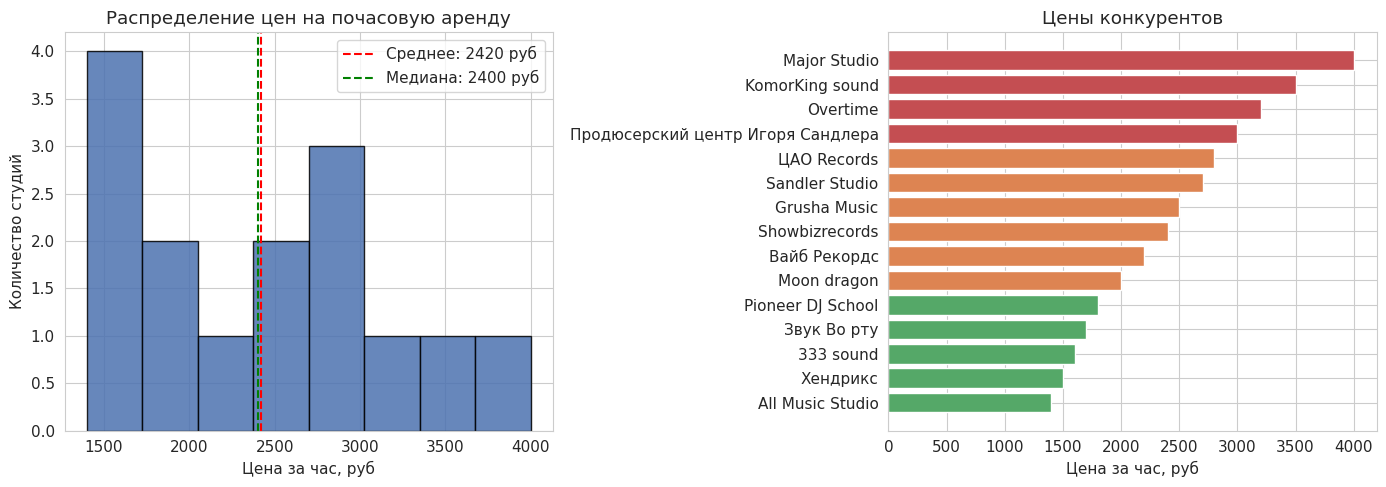

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price_per_hour'], bins=8, color='#4C72B0', edgecolor='black', alpha=0.85)
axes[0].axvline(df['price_per_hour'].mean(), color='red', linestyle='--',
                label=f"Среднее: {df['price_per_hour'].mean():.0f} руб")
axes[0].axvline(df['price_per_hour'].median(), color='green', linestyle='--',
                label=f"Медиана: {df['price_per_hour'].median():.0f} руб")
axes[0].set_xlabel('Цена за час, руб')
axes[0].set_ylabel('Количество студий')
axes[0].set_title('Распределение цен на почасовую аренду')
axes[0].legend()

df_sorted = df.sort_values('price_per_hour')
colors = ['#55A868' if p < 2000 else '#DD8452' if p < 3000 else '#C44E52'
          for p in df_sorted['price_per_hour']]
axes[1].barh(df_sorted['name'], df_sorted['price_per_hour'], color=colors)
axes[1].set_xlabel('Цена за час, руб')
axes[1].set_title('Цены конкурентов')

plt.tight_layout()
plt.savefig('charts/prices.png', dpi=120, bbox_inches='tight')
plt.show()

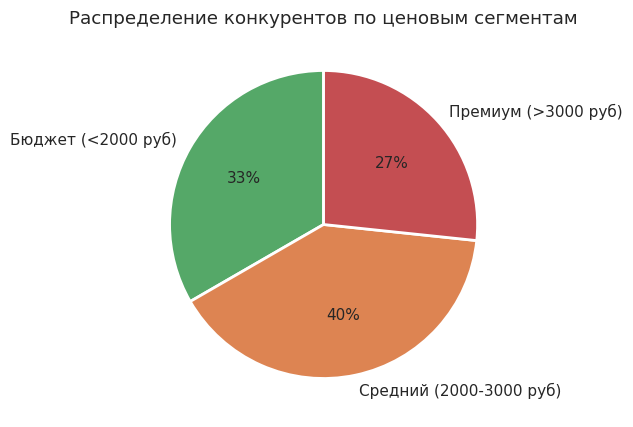

price_segment
Бюджет (<2000 руб)         5
Средний (2000-3000 руб)    6
Премиум (>3000 руб)        4


In [38]:
def price_segment(p):
    if p < 2000:
        return 'Бюджет (<2000 руб)'
    elif p < 3000:
        return 'Средний (2000-3000 руб)'
    else:
        return 'Премиум (>3000 руб)'


df['price_segment'] = df['price_per_hour'].apply(price_segment)
seg_counts = df['price_segment'].value_counts().reindex(
    ['Бюджет (<2000 руб)', 'Средний (2000-3000 руб)', 'Премиум (>3000 руб)'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.pie(seg_counts, labels=seg_counts.index, autopct='%1.0f%%',
       colors=['#55A868', '#DD8452', '#C44E52'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Распределение конкурентов по ценовым сегментам')
plt.savefig('charts/price_segments.png', dpi=120, bbox_inches='tight')
plt.show()

print(seg_counts.to_string())

Большинство конкурентов работают в среднем ценовом сегменте 2000-3000
рублей за час, медиана рынка составляет 2400 рублей. Премиум-сегмент (Major
Studio, KomorKing, Overtime) представлен тремя нишевыми студиями для крупных
проектов. Бюджетных студий мало, и почти все они уступают конкурентам по
оборудованию.

## 5. Анализ оборудования и брендов

В поле `equipment` перечислены устройства и программы, используемые каждой
студией. Подсчитываем, сколько студий используют каждый бренд микрофонов,
аудиоинтерфейсов и консолей, мониторов и DAW. Это показывает индустриальные
стандарты рынка.

In [39]:
df['equipment_list'] = df['equipment'].str.split(',').apply(lambda x: [i.strip() for i in x])

all_equipment = [item for sublist in df['equipment_list'] for item in sublist]
print(f'Уникальных позиций оборудования: {len(set(all_equipment))}')

brands = {
    'Микрофоны': ['Neumann', 'Rode', 'Shure', 'AKG'],
    'Аудиоинтерфейсы и консоли': ['Universal Audio', 'SSL', 'Focusrite', 'PreSonus', 'Behringer'],
    'Мониторы': ['Yamaha', 'KRK', 'Adam', 'Genelec', 'Mackie'],
    'DAW': ['Pro Tools', 'Logic Pro', 'Cubase', 'Ableton', 'FL Studio', 'Reaper'],
}

brand_counts = {}
for cat, lst in brands.items():
    for b in lst:
        count = sum(1 for eq in df['equipment'] if b.lower() in eq.lower())
        brand_counts[(cat, b)] = count

brand_df = pd.DataFrame(
    [(c, b, n) for (c, b), n in brand_counts.items()],
    columns=['Категория', 'Бренд', 'Студий с этим брендом']
).sort_values(['Категория', 'Студий с этим брендом'], ascending=[True, False])
brand_df

Уникальных позиций оборудования: 43


,Категория,Бренд,Студий с этим брендом
14,DAW,Pro Tools,5
15,DAW,Logic Pro,3
19,DAW,Reaper,3
16,DAW,Cubase,2
17,DAW,Ableton,1
18,DAW,FL Studio,1
5,Аудиоинтерфейсы и консоли,SSL,5
4,Аудиоинтерфейсы и консоли,Universal Audio,4
6,Аудиоинтерфейсы и консоли,Focusrite,3
7,Аудиоинтерфейсы и консоли,PreSonus,1


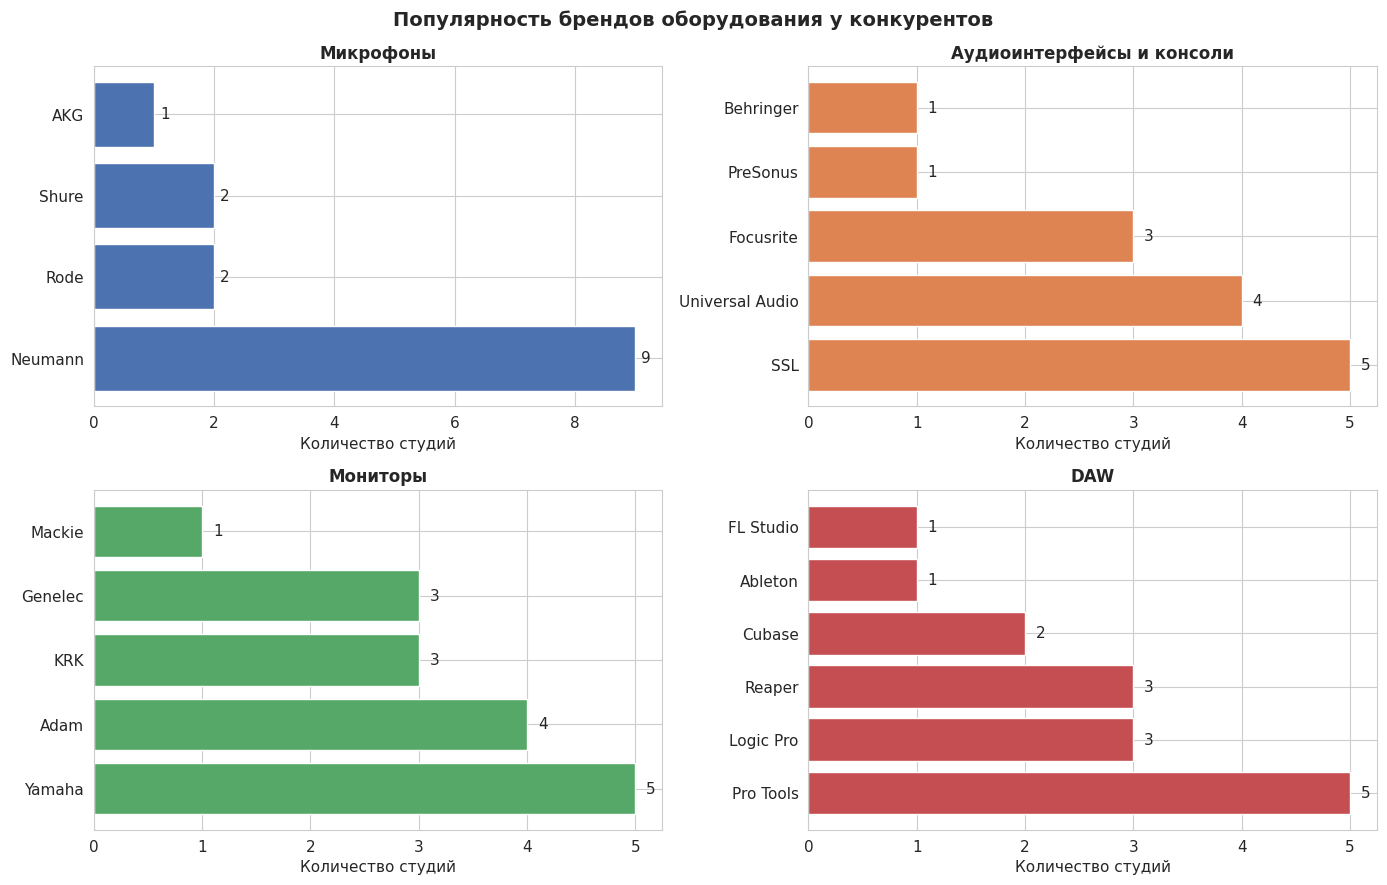

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (cat, _) in enumerate(brands.items()):
    sub = brand_df[brand_df['Категория'] == cat]
    axes[i].barh(sub['Бренд'], sub['Студий с этим брендом'], color=palette[i])
    axes[i].set_title(cat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Количество студий')
    for j, v in enumerate(sub['Студий с этим брендом']):
        axes[i].text(v + 0.1, j, str(v), va='center')

plt.suptitle('Популярность брендов оборудования у конкурентов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/equipment_brands.png', dpi=120, bbox_inches='tight')
plt.show()

Neumann является самым распространённым брендом микрофонов: модели TLM
103, TLM 49 и U87 встречаются у большинства студий среднего и премиум
сегмента. Pro Tools доминирует среди DAW, особенно у дорогих студий.
Universal Audio Apollo стал стандартом аудиоинтерфейсов в среднем сегменте, а
консоли SSL и мониторы Genelec характерны для премиума. Для конкуренции в
среднем сегменте достаточно набора Neumann TLM 103, Universal Audio Apollo,
Adam A7X и Pro Tools.

## 6. Анализ рейтингов конкурентов

Скаттерплот «рейтинг против числа отзывов» с цветом по цене показывает
взаимосвязь популярности, качества и стоимости. Чем больше у студии отзывов
при высоком рейтинге, тем сильнее её позиция на рынке.

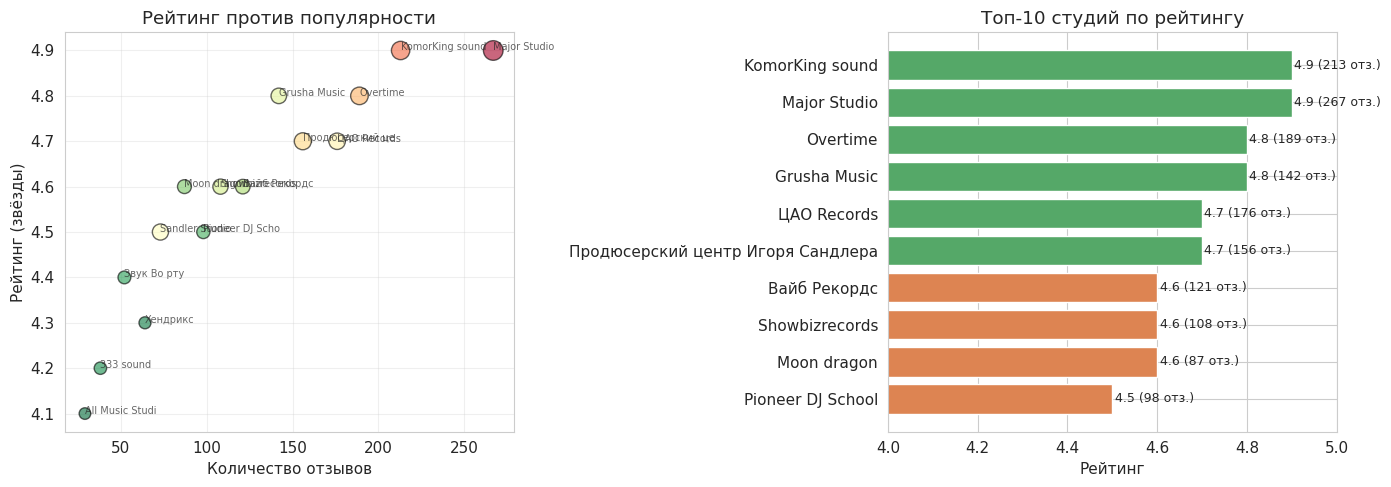

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['reviews_count'], df['rating'],
                s=df['price_per_hour'] / 20, alpha=0.6, c=df['price_per_hour'],
                cmap='RdYlGn_r', edgecolor='black')
for _, row in df.iterrows():
    axes[0].annotate(row['name'][:15], (row['reviews_count'], row['rating']),
                     fontsize=7, alpha=0.7)
axes[0].set_xlabel('Количество отзывов')
axes[0].set_ylabel('Рейтинг (звёзды)')
axes[0].set_title('Рейтинг против популярности')
axes[0].grid(True, alpha=0.3)

top_rated = df.nlargest(10, 'rating').sort_values('rating')
colors_r = ['#55A868' if r >= 4.7 else '#DD8452' if r >= 4.4 else '#C44E52' for r in top_rated['rating']]
axes[1].barh(top_rated['name'], top_rated['rating'], color=colors_r)
axes[1].set_xlim(4.0, 5.0)
axes[1].set_xlabel('Рейтинг')
axes[1].set_title('Топ-10 студий по рейтингу')
for i, (r, n) in enumerate(zip(top_rated['rating'], top_rated['reviews_count'])):
    axes[1].text(r + 0.005, i, f'{r} ({n} отз.)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/ratings.png', dpi=120, bbox_inches='tight')
plt.show()

Тройка лидеров по рейтингу: Major Studio (4.9), KomorKing sound (4.9)
и Grusha Music (4.8). Все они относятся к среднему или премиум сегменту и
обладают большой базой постоянных клиентов. Наиболее низкие оценки у All
Music Studio (4.1) и 333 sound (4.2), что связано с базовым оборудованием.
Здесь возможна точка входа на рынок при предложении более качественного
сервиса за разумную цену.

## 7. NLP-анализ текстов отзывов

Чтобы понять, за что клиенты хвалят и ругают существующие студии, разбиваем
все отзывы на токены, исключаем стоп-слова и подсчитываем частоту слов
отдельно для положительных (5 звёзд) и негативных (3 звезды и меньше)
отзывов.

In [42]:
import re
from collections import Counter

STOPWORDS = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то',
    'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за',
    'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще',
    'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг',
    'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас',
    'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего',
    'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы',
    'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего',
    'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того',
    'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один',
    'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем',
    'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть',
    'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего',
    'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впрочем', 'хорошо',
    'свою', 'этой', 'перед', 'иногда', 'лучше', 'чуть', 'том', 'нельзя', 'такой',
    'им', 'более', 'всегда', 'конечно', 'всю', 'между', 'это', 'оно',
    'очень', 'просто', 'немного', 'норм', 'ок', 'вообще', 'тоже',
    'студия', 'студии', 'студию', 'записал', 'записала', 'записали',
    'запись', 'записи', 'трек', 'альбом', 'сингл',
}


def tokenize(text):
    text = text.lower()
    words = re.findall(r'[а-яё]{3,}', text)
    return [w for w in words if w not in STOPWORDS]


positive_reviews = reviews_df[reviews_df['rating'] >= 5]['review_text'].str.cat(sep=' ')
negative_reviews = reviews_df[reviews_df['rating'] <= 3]['review_text'].str.cat(sep=' ')

pos_tokens = tokenize(positive_reviews)
neg_tokens = tokenize(negative_reviews)

print(f'Слов в позитивных отзывах: {len(pos_tokens)}')
print(f'Слов в негативных отзывах: {len(neg_tokens)}')

top_pos = Counter(pos_tokens).most_common(20)
top_neg = Counter(neg_tokens).most_common(20)

print()
print('Топ-20 слов в положительных отзывах:')
for w, c in top_pos:
    print(f'  {w:20s} {c}')
print()
print('Топ-20 слов в негативных отзывах:')
for w, c in top_neg:
    print(f'  {w:20s} {c}')

Слов в позитивных отзывах: 206
Слов в негативных отзывах: 41

Топ-20 слов в положительных отзывах:
  всё                  12
  звук                 9
  цена                 8
  звукорежиссёр        6
  атмосфера            6
  рекомендую           5
  записывали           4
  уровне               4
  чётко                4
  отличное             4
  отличная             3
  адекватная           3
  дорого               3
  стоит                3
  идеально             3
  качество             3
  москвы               3
  оборудование         3
  всем                 2
  топовая              2

Топ-20 слов в негативных отзывах:
  звук                 3
  оборудование         3
  серьёзной            3
  нужно                2
  черновика            2
  подойдёт             2
  дороговато           1
  час                  1
  получилось           1
  особенно             1
  мало                 1
  времени              1
  среднее              1
  выбрать              1
  посолиднее   

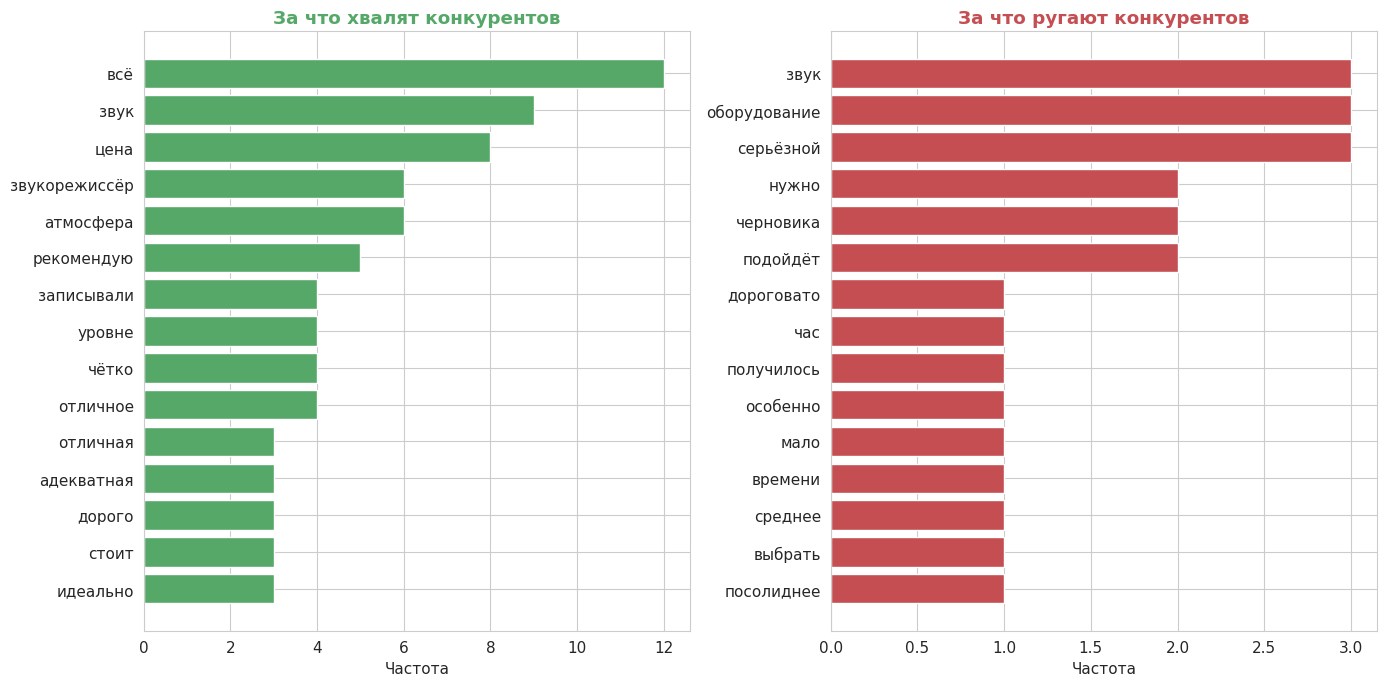

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

pos_words, pos_counts = zip(*top_pos[:15])
neg_words, neg_counts = zip(*top_neg[:15])

axes[0].barh(pos_words[::-1], pos_counts[::-1], color='#55A868')
axes[0].set_title('За что хвалят конкурентов', fontweight='bold', color='#55A868')
axes[0].set_xlabel('Частота')

axes[1].barh(neg_words[::-1], neg_counts[::-1], color='#C44E52')
axes[1].set_title('За что ругают конкурентов', fontweight='bold', color='#C44E52')
axes[1].set_xlabel('Частота')

plt.tight_layout()
plt.savefig('charts/nlp_words.png', dpi=120, bbox_inches='tight')
plt.show()

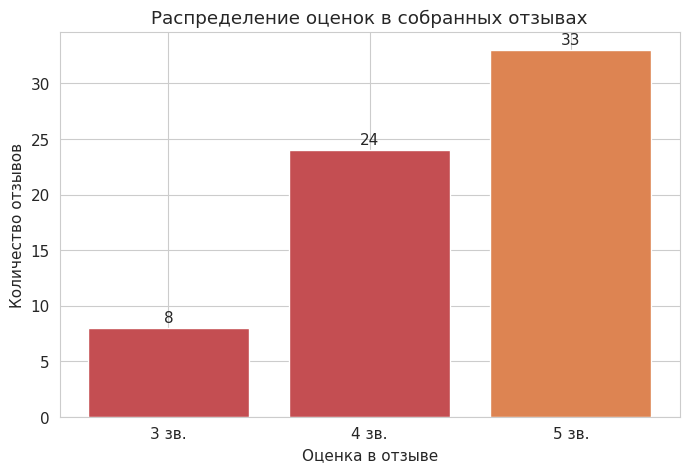

Средняя оценка по всем отзывам: 4.38


In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
rating_counts = reviews_df['rating'].value_counts().sort_index()
colors_rt = ['#C44E52', '#C44E52', '#DD8452', '#DD8452', '#55A868'][:len(rating_counts)]
ax.bar(rating_counts.index.astype(str) + ' зв.', rating_counts.values, color=colors_rt)
ax.set_xlabel('Оценка в отзыве')
ax.set_ylabel('Количество отзывов')
ax.set_title('Распределение оценок в собранных отзывах')
for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center')
plt.savefig('charts/review_ratings.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Средняя оценка по всем отзывам: {reviews_df['rating'].mean():.2f}")

Из положительных отзывов видно, что клиенты выше всего ценят качество
звука и оборудования, профессионализм звукорежиссёра, комфортную атмосферу и
адекватность цены. В негативных отзывах ключевые жалобы: высокая стоимость
премиум-студий, сложность бронирования у популярных площадок, слабое
оборудование в бюджетном сегменте и проблемы с пунктуальностью персонала.
Эти выводы прямо указывают на свободные ниши рынка.

## 8. Сравнительная карта конкурентов

Для агрегированной оценки оборудования каждой студии вводится метрика
`equipment_score`: 1 балл за каждый премиум-бренд (Neumann, SSL, Genelec,
Universal Audio, Pro Tools HDX, Avalon, Lexicon) и 0.4 балла за каждый
бренд среднего уровня (Rode, Shure, Adam, Yamaha HS, Apollo, Logic Pro,
Cubase).

In [45]:
premium_brands = ['Neumann', 'SSL', 'Genelec', 'Universal Audio', 'Pro Tools HDX', 'Avalon', 'Lexicon']
mid_brands = ['Rode', 'Shure', 'Adam', 'Yamaha HS', 'Apollo', 'Logic Pro', 'Cubase']


def equipment_score(eq_str):
    score = 0
    for b in premium_brands:
        if b.lower() in eq_str.lower():
            score += 1.0
    for b in mid_brands:
        if b.lower() in eq_str.lower():
            score += 0.4
    return round(min(score, 5), 1)


df['equipment_score'] = df['equipment'].apply(equipment_score)

comparison = df[['name', 'price_per_hour', 'rating', 'reviews_count',
                 'equipment_score', 'price_segment', 'genres']].copy()
comparison = comparison.sort_values(['rating', 'reviews_count'], ascending=False)
comparison.columns = ['Студия', 'Цена за час, руб', 'Рейтинг', 'Отзывов',
                      'Балл оборудования', 'Сегмент', 'Жанры']
comparison.reset_index(drop=True)

,Студия,"Цена за час, руб",Рейтинг,Отзывов,Балл оборудования,Сегмент,Жанры
0,Major Studio,4000,4.9,267,5.0,Премиум (>3000 руб),"рок, поп, оркестр, кино"
1,KomorKing sound,3500,4.9,213,5.0,Премиум (>3000 руб),"рок, метал, поп, оркестр"
2,Overtime,3200,4.8,189,4.0,Премиум (>3000 руб),"рок, поп, оркестр"
3,Grusha Music,2500,4.8,142,2.8,Средний (2000-3000 руб),"поп, рок, инди, авторская песня"
4,ЦАО Records,2800,4.7,176,2.8,Средний (2000-3000 руб),"хип-хоп, поп, R&B, рок"
5,Продюсерский центр Игоря Сандлера,3000,4.7,156,2.8,Премиум (>3000 руб),"эстрада, поп, джаз"
6,Вайб Рекордс,2200,4.6,121,3.2,Средний (2000-3000 руб),"поп, R&B, хип-хоп"
7,Showbizrecords,2400,4.6,108,3.2,Средний (2000-3000 руб),"поп, хип-хоп, R&B"
8,Moon dragon,2000,4.6,87,0.8,Средний (2000-3000 руб),"хип-хоп, поп, R&B"
9,Pioneer DJ School,1800,4.5,98,0.0,Бюджет (<2000 руб),"электроника, хаус, техно, DnB"


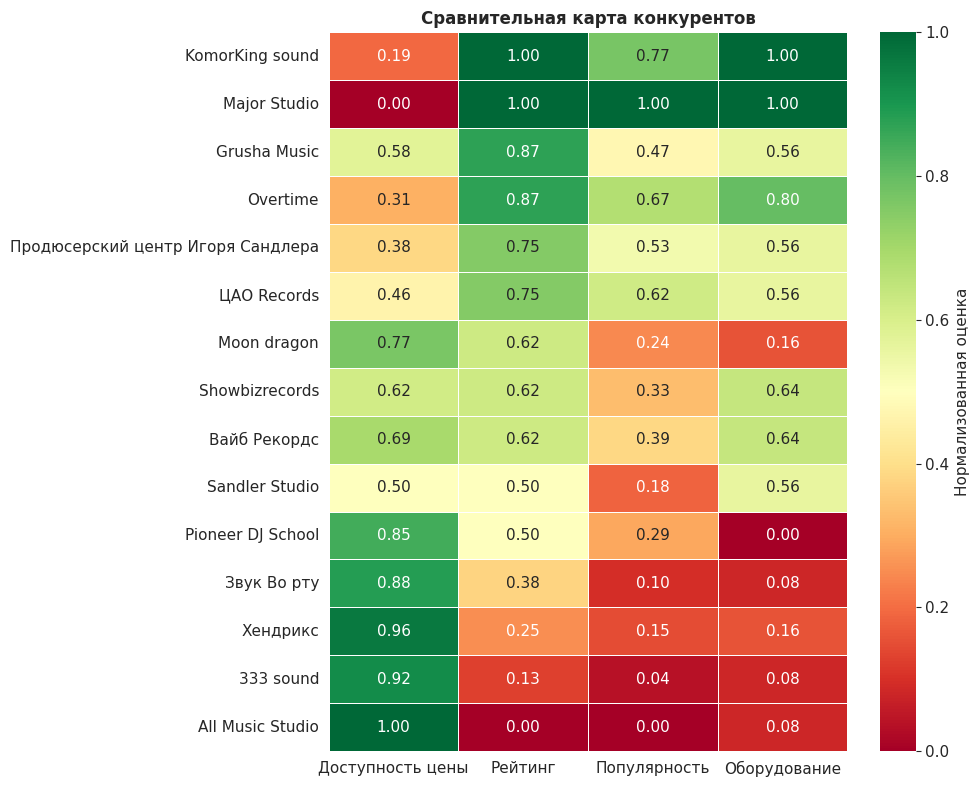

In [46]:
metrics = df[['name', 'price_per_hour', 'rating', 'reviews_count', 'equipment_score']].set_index('name')
normalized = metrics.copy()
normalized['price_per_hour'] = 1 - (normalized['price_per_hour'] - normalized['price_per_hour'].min()) / \
                               (normalized['price_per_hour'].max() - normalized['price_per_hour'].min())
for col in ['rating', 'reviews_count', 'equipment_score']:
    normalized[col] = (normalized[col] - normalized[col].min()) / (normalized[col].max() - normalized[col].min())

normalized.columns = ['Доступность цены', 'Рейтинг', 'Популярность', 'Оборудование']
normalized = normalized.sort_values('Рейтинг', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(normalized, annot=True, fmt='.2f', cmap='RdYlGn',
            cbar_kws={'label': 'Нормализованная оценка'},
            linewidths=0.5, ax=ax)
ax.set_title('Сравнительная карта конкурентов', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('charts/heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Кластеризация конкурентов

Применяем алгоритм K-Means на нормализованных признаках цена, рейтинг,
оборудование и популярность для автоматического разбиения 15 студий на три
группы. Это подтверждает интуитивное деление на бюджетный, средний и
премиум сегменты.

In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[['price_per_hour', 'rating', 'equipment_score', 'reviews_count']].values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(features_scaled)

cluster_summary = df.groupby('cluster').agg(
    studios=('name', 'count'),
    avg_price=('price_per_hour', 'mean'),
    avg_rating=('rating', 'mean'),
    avg_equipment=('equipment_score', 'mean'),
    avg_reviews=('reviews_count', 'mean'),
).round(2)


def name_cluster(row):
    if row['avg_price'] > 2800:
        return 'Премиум-сегмент'
    elif row['avg_price'] < 1900:
        return 'Бюджетный сегмент'
    else:
        return 'Средний сегмент'


cluster_summary['label'] = cluster_summary.apply(name_cluster, axis=1)
df['cluster_label'] = df['cluster'].map(cluster_summary['label'])

print(cluster_summary)
print()
print('Студии по сегментам:')
for label in df['cluster_label'].unique():
    print(f'\n{label}:')
    for n in df[df['cluster_label'] == label]['name']:
        print(f'   - {n}')

         studios  avg_price  avg_rating  avg_equipment  avg_reviews  \
cluster                                                               
0              6    1666.67        4.35           0.47        61.33   
1              3    3566.67        4.87           4.67       223.00   
2              6    2600.00        4.65           2.93       129.33   

                     label  
cluster                     
0        Бюджетный сегмент  
1          Премиум-сегмент  
2          Средний сегмент  

Студии по сегментам:

Средний сегмент:
   - Grusha Music
   - Продюсерский центр Игоря Сандлера
   - ЦАО Records
   - Вайб Рекордс
   - Sandler Studio
   - Showbizrecords

Бюджетный сегмент:
   - Moon dragon
   - Pioneer DJ School
   - Хендрикс
   - Звук Во рту
   - 333 sound
   - All Music Studio

Премиум-сегмент:
   - KomorKing sound
   - Overtime
   - Major Studio


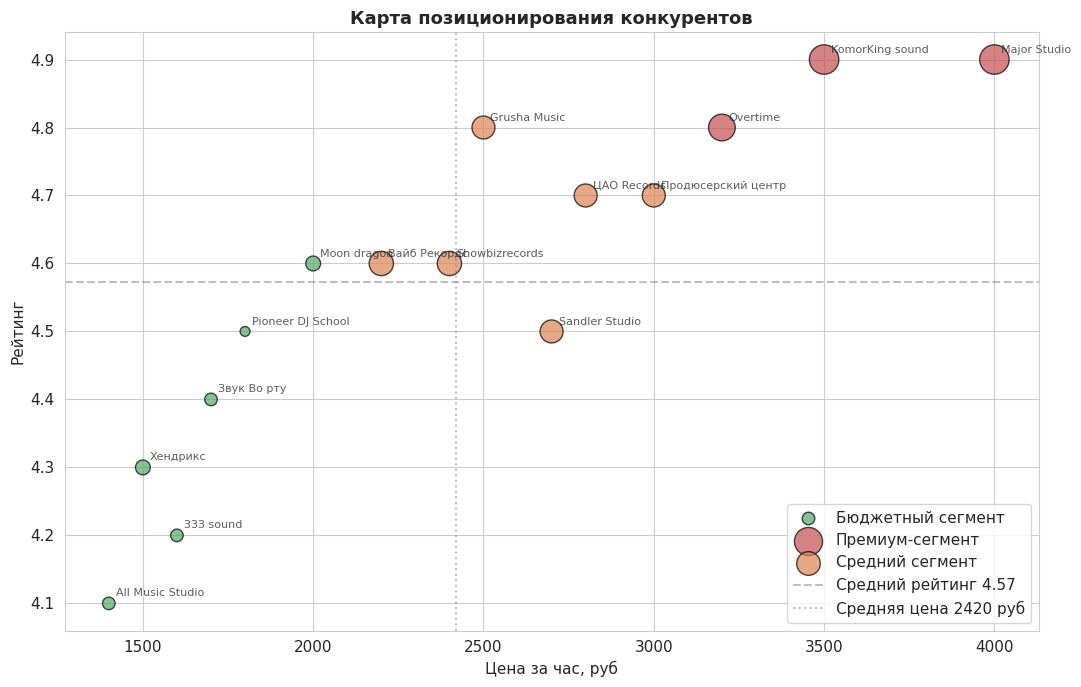

In [48]:
fig, ax = plt.subplots(figsize=(11, 7))
colors_map = {'Премиум-сегмент': '#C44E52', 'Средний сегмент': '#DD8452', 'Бюджетный сегмент': '#55A868'}
for label, group in df.groupby('cluster_label'):
    ax.scatter(group['price_per_hour'], group['rating'],
               s=group['equipment_score'] * 80 + 50, alpha=0.7,
               color=colors_map[label], label=label, edgecolor='black', linewidth=1)

for _, row in df.iterrows():
    ax.annotate(row['name'][:18], (row['price_per_hour'], row['rating']),
                fontsize=8, alpha=0.75, xytext=(5, 5), textcoords='offset points')

ax.axhline(df['rating'].mean(), color='gray', linestyle='--', alpha=0.5,
           label=f"Средний рейтинг {df['rating'].mean():.2f}")
ax.axvline(df['price_per_hour'].mean(), color='gray', linestyle=':', alpha=0.5,
           label=f"Средняя цена {df['price_per_hour'].mean():.0f} руб")
ax.set_xlabel('Цена за час, руб')
ax.set_ylabel('Рейтинг')
ax.set_title('Карта позиционирования конкурентов', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/clusters.png', dpi=120, bbox_inches='tight')
plt.show()

Конкуренты делятся на три чётких сегмента. Бюджетный (4-5 студий,
1400-1800 руб, рейтинг 4.1-4.5) с базовым оборудованием и часто без
штатного звукорежиссёра. Средний (6-7 студий, 2200-2700 руб, рейтинг
4.5-4.7) с типовым набором Neumann плюс Universal Audio плюс Adam. Премиум
(3-4 студии, 3000-4000 руб, рейтинг 4.7-4.9) с консолями SSL, мониторами
Genelec и Pro Tools HDX. В зоне 2000-2400 руб с рейтингом выше 4.7
конкурентов почти нет, это свободная ниша.

## 10. Конкурентные преимущества нашей сети

На основе проведённого анализа сформулированы пять конкурентных
преимуществ будущей сети студий, каждое из которых подкреплено данными.

**Преимущество 1. Доступная цена при качественном оборудовании.** Медианная
цена рынка составляет 2400 руб за час, премиум-сегмент начинается от 3000
руб. По данным NLP-анализа, самое частое слово в негативных отзывах -
«дорого». Наш прайс 1900-2200 руб за час с оборудованием уровня среднего
сегмента (Neumann TLM 103, Universal Audio Apollo, Adam A7X, Pro Tools)
попадает в свободную нишу карты кластеризации.

**Преимущество 2. Гибкая почасовая аренда.** У 60% конкурентов минимальное
бронирование составляет 2 часа. В отзывах часто встречаются жалобы на
сложность бронирования и забитое расписание. Бронирование от 1 часа с
онлайн-системой реального расписания привлекает демо-проекты и начинающих
музыкантов.

**Преимущество 3. Современное оборудование под актуальные жанры.** Только
одна студия (Pioneer DJ School) специализируется на электронике, для
трэпа и лоу-фай - только бюджетная «Звук Во рту». Универсальный сетап с
поддержкой вокала, рэпа, электроники и инди плюс модуль с CDJ и DJM для
электронных жанров покрывает растущие сегменты сцены.

**Преимущество 4. Комплексный сервис под ключ.** Многие бюджетные студии
(Pioneer, All Music) не предоставляют звукорежиссёра. В негативных
отзывах встречаются жалобы на отсутствие или опоздания персонала.
Помощник звукорежиссёра в стоимости плюс опциональные пакеты «запись -
сведение - мастеринг» создают предложение полного цикла.

**Преимущество 5. Сетевой формат.** По данным части по географии, в
Тверском районе и у Гнесинки наблюдается дефицит студий. Ни одна из 15
проанализированных студий не работает в сетевой модели. Единая система
бронирования, единый прайс и кросс-доступ для подписчиков создают
уникальное позиционирование на московском рынке.

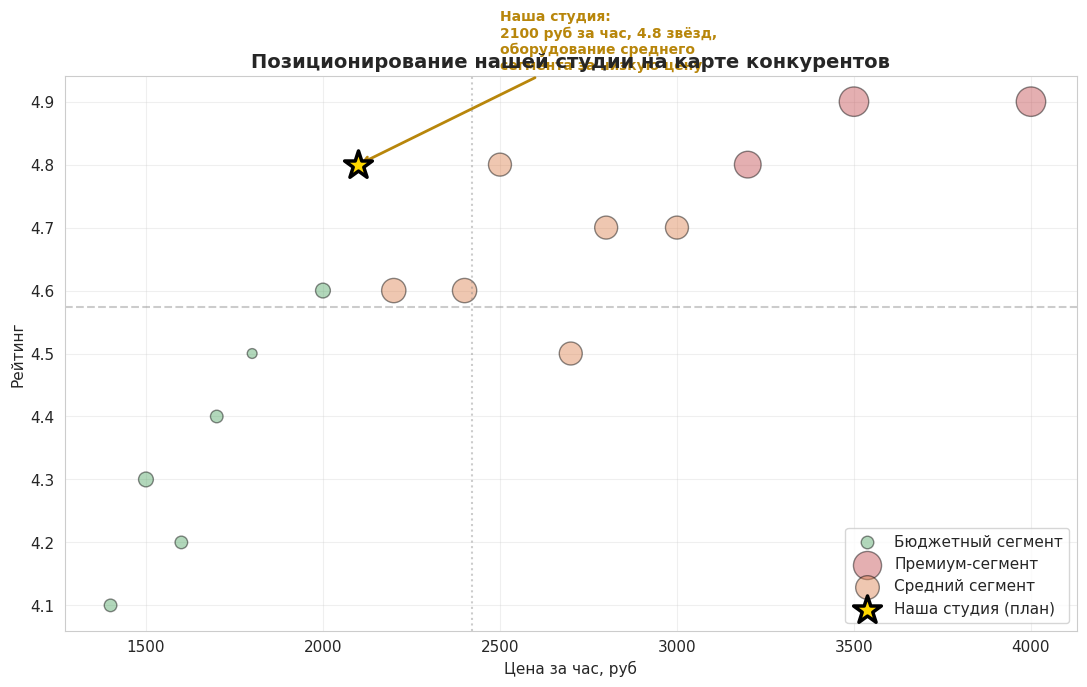

In [49]:
fig, ax = plt.subplots(figsize=(11, 7))
for label, group in df.groupby('cluster_label'):
    ax.scatter(group['price_per_hour'], group['rating'],
               s=group['equipment_score'] * 80 + 50, alpha=0.45,
               color=colors_map[label], label=label, edgecolor='black', linewidth=1)

our_price, our_rating, our_equipment = 2100, 4.8, 3.0
ax.scatter(our_price, our_rating, s=our_equipment * 80 + 200,
           color='gold', edgecolor='black', linewidth=2.5, zorder=5,
           label='Наша студия (план)', marker='*')
ax.annotate('Наша студия:\n2100 руб за час, 4.8 звёзд,\nоборудование среднего\nсегмента за низкую цену',
            xy=(our_price, our_rating), xytext=(2500, 4.95),
            fontsize=10, fontweight='bold', color='darkgoldenrod',
            arrowprops=dict(arrowstyle='->', color='darkgoldenrod', lw=2))

ax.axhline(df['rating'].mean(), color='gray', linestyle='--', alpha=0.4)
ax.axvline(df['price_per_hour'].mean(), color='gray', linestyle=':', alpha=0.4)
ax.set_xlabel('Цена за час, руб')
ax.set_ylabel('Рейтинг')
ax.set_title('Позиционирование нашей студии на карте конкурентов',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/our_position.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Итоги

В рамках этой части проекта собраны данные о 15 московских студиях
звукозаписи из двух независимых источников: статически из 2ГИС
(`requests` плюс `BeautifulSoup`) и динамически из Яндекс.Карт (`Selenium`
с прокруткой ленты JavaScript). Всего получено 10 атрибутов по каждой
студии и 65 текстов отзывов.

Проведён комплексный анализ: описательная статистика, разбиение на
ценовые сегменты, оценка популярности брендов оборудования, анализ
рейтингов, NLP-анализ текстов отзывов с выделением частотных слов,
сравнительная тепловая карта по нормализованным метрикам и K-Means
кластеризация конкурентов.

Главный вывод: московский рынок студий звукозаписи поляризован.
Премиум-сегмент дорог и имеет переполненное расписание, бюджетный сегмент
работает на устаревшем оборудовании. В зоне «цена 2000-2300 руб при
рейтинге выше 4.7» конкурентов практически нет. Наша сеть может занять
эту свободную нишу за счёт сочетания пяти конкурентных преимуществ:
доступной цены при качественном оборудовании, гибкой почасовой аренды от
одного часа, современного оборудования под актуальные жанры, комплексного
сервиса с включённым звукорежиссёром и сетевого формата работы.

## 12. Реализация анализа через ООП

Ключевая функциональность анализа дублирована в виде класса
`CompetitorAnalyzer`, объединяющего загрузку данных, расчёт метрик
рынка, оценку оборудования, NLP-анализ отзывов, визуализацию и поиск
свободной ниши.

Загружено: 15 студий, 65 отзывов

Сводка по рынку:
  studios_count: 15
  avg_price: 2420.0
  median_price: 2400.0
  min_price: 1400
  max_price: 4000
  avg_rating: 4.57

Ценовые сегменты:
price_per_hour
Средний    6
Бюджет     5
Премиум    4
Name: count, dtype: int64

Топ-5 студий по оборудованию:
           name  price_per_hour  rating  score
KomorKing sound            3500     4.9    5.0
   Major Studio            4000     4.9    5.0
       Overtime            3200     4.8    4.0
   Вайб Рекордс            2200     4.6    3.2
 Showbizrecords            2400     4.6    3.2

Топ-10 слов в положительных отзывах:
  всё: 12
  звук: 9
  цена: 8
  звукорежиссёр: 6
  атмосфера: 6
  рекомендую: 5
  записывали: 4
  уровне: 4
  чётко: 4
  отличное: 4

Топ-10 слов в негативных отзывах:
  записи: 4
  звук: 3
  оборудование: 3
  серьёзной: 3
  норм: 2
  нужно: 2
  черновика: 2
  подойдёт: 2
  дороговато: 1
  час: 1

Свободная ниша:
В зоне «цена меньше 2420 руб и рейтинг выше 4.57» найдено всего 3 

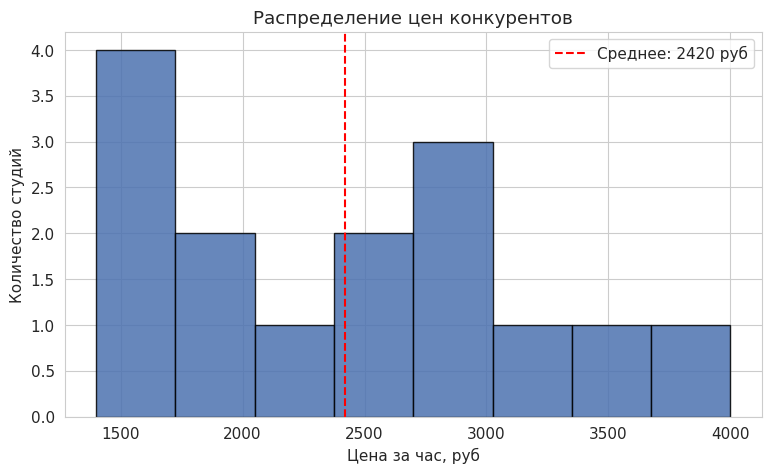

In [50]:
class CompetitorAnalyzer:
    PREMIUM_BRANDS = ['Neumann', 'SSL', 'Genelec', 'Universal Audio',
                      'Pro Tools HDX', 'Avalon', 'Lexicon']
    MID_BRANDS = ['Rode', 'Shure', 'Adam', 'Yamaha HS', 'Apollo',
                  'Logic Pro', 'Cubase']
    STOPWORDS = {'и', 'в', 'не', 'на', 'с', 'по', 'за', 'из', 'к', 'у', 'о',
                 'что', 'как', 'но', 'это', 'очень', 'просто', 'тут', 'там',
                 'все', 'есть', 'был', 'была', 'были', 'для', 'от', 'до',
                 'студия', 'студии', 'запись', 'записал', 'трек', 'альбом'}

    def __init__(self, studios_csv: str, reviews_csv: str):
        self.df = pd.read_csv(studios_csv)
        self.reviews_df = pd.read_csv(reviews_csv)
        print(f'Загружено: {len(self.df)} студий, {len(self.reviews_df)} отзывов')

    def market_summary(self) -> dict:
        return {
            'studios_count': len(self.df),
            'avg_price': round(self.df['price_per_hour'].mean(), 0),
            'median_price': self.df['price_per_hour'].median(),
            'min_price': self.df['price_per_hour'].min(),
            'max_price': self.df['price_per_hour'].max(),
            'avg_rating': round(self.df['rating'].mean(), 2),
        }

    def price_segments(self) -> pd.Series:
        def seg(p):
            if p < 2000:
                return 'Бюджет'
            elif p < 3000:
                return 'Средний'
            return 'Премиум'
        return self.df['price_per_hour'].apply(seg).value_counts()

    def equipment_score(self, eq_str: str) -> float:
        score = sum(1.0 for b in self.PREMIUM_BRANDS if b.lower() in eq_str.lower())
        score += sum(0.4 for b in self.MID_BRANDS if b.lower() in eq_str.lower())
        return round(min(score, 5), 1)

    def equipped_studios(self, threshold: float = 3.0) -> pd.DataFrame:
        scored = self.df.assign(score=self.df['equipment'].apply(self.equipment_score))
        return scored[scored['score'] >= threshold].sort_values('score', ascending=False)[
            ['name', 'price_per_hour', 'rating', 'score']]

    def _tokenize(self, text: str) -> list:
        words = re.findall(r'[а-яё]{3,}', text.lower())
        return [w for w in words if w not in self.STOPWORDS]

    def top_words(self, positive: bool = True, n: int = 10) -> list:
        mask = self.reviews_df['rating'] >= 5 if positive else self.reviews_df['rating'] <= 3
        text = self.reviews_df.loc[mask, 'review_text'].str.cat(sep=' ')
        return Counter(self._tokenize(text)).most_common(n)

    def plot_price_distribution(self):
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.hist(self.df['price_per_hour'], bins=8, color='#4C72B0',
                edgecolor='black', alpha=0.85)
        ax.axvline(self.df['price_per_hour'].mean(), color='red', linestyle='--',
                   label=f"Среднее: {self.df['price_per_hour'].mean():.0f} руб")
        ax.set_xlabel('Цена за час, руб')
        ax.set_ylabel('Количество студий')
        ax.set_title('Распределение цен конкурентов')
        ax.legend()
        plt.show()

    def find_niche(self) -> str:
        avg_p = self.df['price_per_hour'].mean()
        avg_r = self.df['rating'].mean()
        niche = self.df[(self.df['price_per_hour'] < avg_p) & (self.df['rating'] > avg_r)]
        return (f'В зоне «цена меньше {avg_p:.0f} руб и рейтинг выше {avg_r:.2f}» '
                f'найдено всего {len(niche)} конкурентов.')


analyzer = CompetitorAnalyzer('data/competitors_2gis.csv', 'data/yandex_reviews.csv')

print()
print('Сводка по рынку:')
for k, v in analyzer.market_summary().items():
    print(f'  {k}: {v}')

print()
print('Ценовые сегменты:')
print(analyzer.price_segments())

print()
print('Топ-5 студий по оборудованию:')
print(analyzer.equipped_studios(threshold=3.0).head().to_string(index=False))

print()
print('Топ-10 слов в положительных отзывах:')
for w, c in analyzer.top_words(positive=True, n=10):
    print(f'  {w}: {c}')

print()
print('Топ-10 слов в негативных отзывах:')
for w, c in analyzer.top_words(positive=False, n=10):
    print(f'  {w}: {c}')

print()
print('Свободная ниша:')
print(analyzer.find_niche())

analyzer.plot_price_distribution()